In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Simulated ground truth
# -----------------------------
dt = 0.1
t = np.arange(0, 20, dt)
n = len(t)

print(f"t = {t}")
print(f"len(t) = {len(t)}")

t = [ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10.  10.1 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1
 11.2 11.3 11.4 11.5 11.6 11.7 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5
 12.6 12.7 12.8 12.9 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9
 14.  14.1 14.2 14.3 14.4 14.5 14.6 14.7 14.8 14.9 15.  15.1 15.2 15.3
 15.4 15.5 15.6 15.7 15.8 15.9 16.  16.1 16.2 16.3 16.4 16.5 16.6 16.7
 16.8 16.9 17.  17.1 17.2 17.3 17.4 17.5 17.6 17.7 17.8 17.9 18.  18.1
 18.2 18.3 18.4 18.5 18.6 18.7 18.8 18.9 19.  19.1 19.2 19.3 19.4 19.5
 1

In [3]:
true_acc = 0.2 * np.sin(0.5 * t)   # changing acceleration
true_pos = np.zeros(n)
true_vel = np.zeros(n)

In [5]:
for k in range(1, n):
    true_vel[k] = true_vel[k-1] + true_acc[k-1] * dt
    true_pos[k] = true_pos[k-1] + true_vel[k-1] * dt + 0.5 * true_acc[k-1] * dt**2

Text(0.5, 1.0, 'True Velocity')

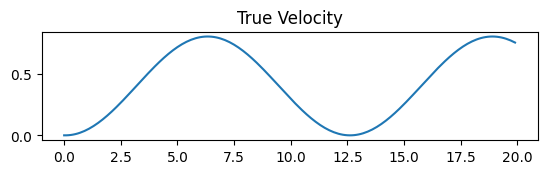

In [8]:
plt.subplot(3, 1, 2)
plt.plot(t, true_vel, label='True Velocity')
plt.title('True Velocity')

In [12]:
# -----------------------------
# Simulated sensors
# -----------------------------
np.random.seed(42)

# Accelerometer is noisy
acc_measured = true_acc + np.random.normal(0, 0.15, size=n)

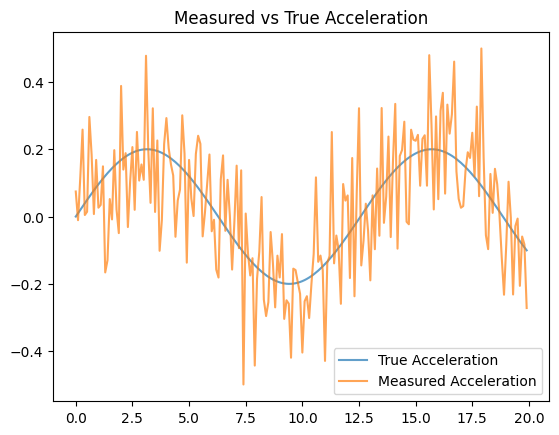

In [14]:
plt.plot(t, true_acc, label='True Acceleration', alpha=0.7)
plt.plot(t, acc_measured, label='Measured Acceleration', alpha=0.7)
plt.title('Measured vs True Acceleration')
plt.legend()

In [15]:
# GPS position is noisy
gps_measured = true_pos + np.random.normal(0, 2.0, size=n)

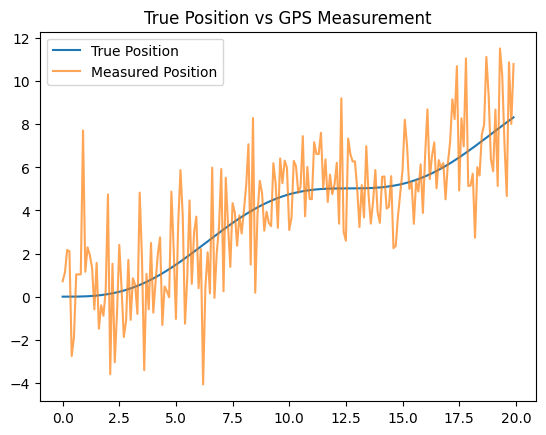

In [17]:
plt.plot(t, true_pos, label='True Position')
plt.plot(t, gps_measured, label='Measured Position', alpha=0.7)
plt.title('True Position vs GPS Measurement')
plt.legend()

In [18]:
# -----------------------------
# Kalman Filter setup
# -----------------------------
# State x = [position, velocity]^T
x = np.array([[0.0],
              [0.0]])

# Covariance matrix
P = np.array([[10.0, 0.0],
              [0.0, 10.0]])

# State transition model
A = np.array([[1, dt],
              [0, 1]])

# Control input model (acceleration)
B = np.array([[0.5 * dt**2],
              [dt]])

# Measurement model (GPS measures position only)
H = np.array([[1, 0]])

# Process noise covariance
Q = np.array([[0.01, 0.0],
              [0.0, 0.03]])

# Measurement noise covariance
R = np.array([[4.0]])   # GPS noise variance (2.0^2)

In [19]:
# Store estimates
estimated_pos = []
estimated_vel = []

In [20]:
# -----------------------------
# Kalman Filter loop
# -----------------------------
for k in range(n):
    u = np.array([[acc_measured[k]]])   # measured acceleration
    z = np.array([[gps_measured[k]]])   # measured GPS position

    # 1. Predict
    x = A @ x + B @ u
    P = A @ P @ A.T + Q

    # 2. Update
    y = z - H @ x                              # innovation
    S = H @ P @ H.T + R                        # innovation covariance
    K = P @ H.T @ np.linalg.inv(S)             # Kalman gain

    x = x + K @ y
    P = (np.eye(2) - K @ H) @ P

    estimated_pos.append(x[0, 0])
    estimated_vel.append(x[1, 0])

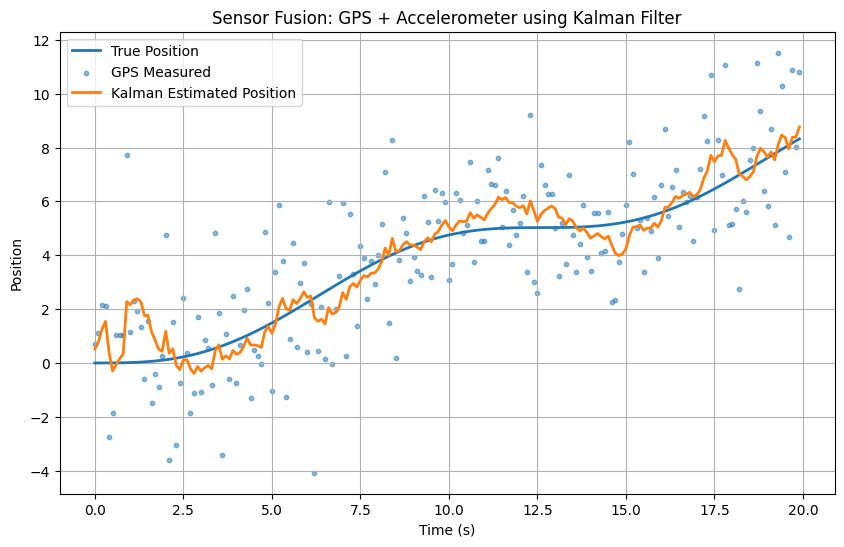

In [21]:
# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(t, true_pos, label="True Position", linewidth=2)
plt.scatter(t, gps_measured, label="GPS Measured", s=10, alpha=0.5)
plt.plot(t, estimated_pos, label="Kalman Estimated Position", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Position")
plt.title("Sensor Fusion: GPS + Accelerometer using Kalman Filter")
plt.legend()
plt.grid(True)
plt.show()

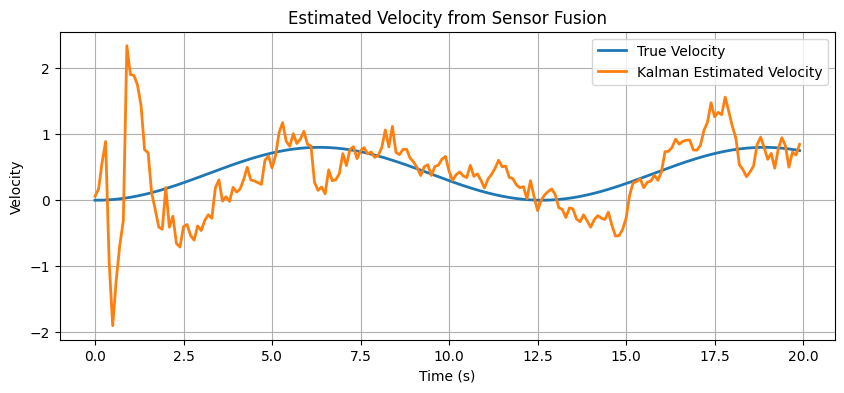

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(t, true_vel, label="True Velocity", linewidth=2)
plt.plot(t, estimated_vel, label="Kalman Estimated Velocity", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Velocity")
plt.title("Estimated Velocity from Sensor Fusion")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
import cv2

# Create Kalman Filter
# Parameters: state dimension, measurement dimension, control dimension
kf = cv2.KalmanFilter(2, 1, 1)

# State transition matrix A
kf.transitionMatrix = np.array([[1, dt],
                                 [0, 1]], dtype=np.float32)

# Measurement matrix H (we measure position only)
kf.measurementMatrix = np.array([[1, 0]], dtype=np.float32)

# Process noise covariance Q
kf.processNoiseCov = np.array([[0.01, 0.0],
                                [0.0, 0.03]], dtype=np.float32)

# Measurement noise covariance R
kf.measurementNoiseCov = np.array([[4.0]], dtype=np.float32)

# Control matrix B (for acceleration input)
kf.controlMatrix = np.array([[0.5 * dt**2],
                              [dt]], dtype=np.float32)

# Initial state covariance P
kf.errorCovPost = np.array([[10.0, 0.0],
                             [0.0, 10.0]], dtype=np.float32)

# Initial state
kf.statePost = np.array([[0.0],
                          [0.0]], dtype=np.float32)

# OpenCV Kalman Filter Implementation

Same sensor fusion problem using OpenCV's built-in Kalman Filter

In [29]:
# Run OpenCV Kalman Filter
cv_estimated_pos = []
cv_estimated_vel = []

for k in range(n):
    # Control input (acceleration)
    control = np.array([[acc_measured[k]]], dtype=np.float32)
    
    # Predict step
    prediction = kf.predict(control)
    
    # Measurement (GPS position)
    measurement = np.array([[gps_measured[k]]], dtype=np.float32)
    
    # Update step
    corrected = kf.correct(measurement)
    
    cv_estimated_pos.append(corrected[0, 0])
    cv_estimated_vel.append(corrected[1, 0])

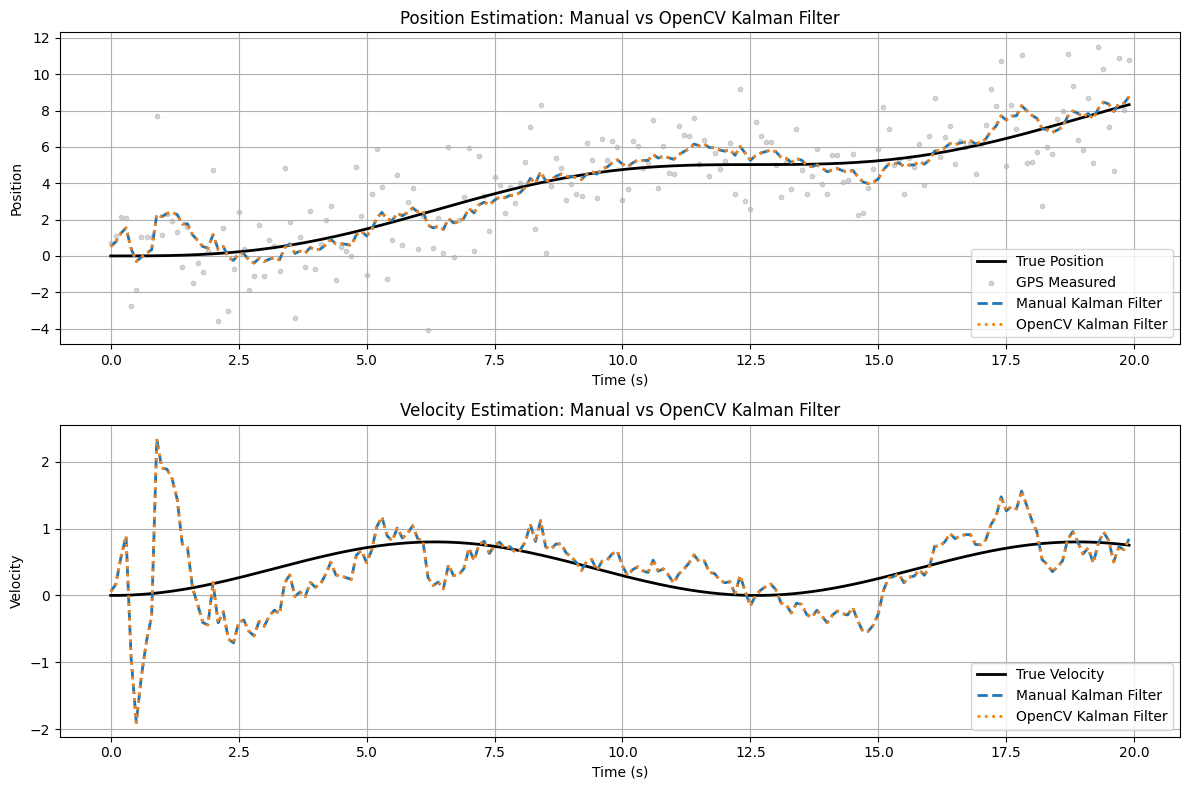

In [30]:
# Compare OpenCV vs Manual implementation
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, true_pos, label="True Position", linewidth=2, color='black')
plt.scatter(t, gps_measured, label="GPS Measured", s=10, alpha=0.3, color='gray')
plt.plot(t, estimated_pos, label="Manual Kalman Filter", linewidth=2, linestyle='--')
plt.plot(t, cv_estimated_pos, label="OpenCV Kalman Filter", linewidth=2, linestyle=':')
plt.xlabel("Time (s)")
plt.ylabel("Position")
plt.title("Position Estimation: Manual vs OpenCV Kalman Filter")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, true_vel, label="True Velocity", linewidth=2, color='black')
plt.plot(t, estimated_vel, label="Manual Kalman Filter", linewidth=2, linestyle='--')
plt.plot(t, cv_estimated_vel, label="OpenCV Kalman Filter", linewidth=2, linestyle=':')
plt.xlabel("Time (s)")
plt.ylabel("Velocity")
plt.title("Velocity Estimation: Manual vs OpenCV Kalman Filter")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
# Calculate errors
manual_pos_error = np.mean(np.abs(np.array(estimated_pos) - true_pos))
opencv_pos_error = np.mean(np.abs(np.array(cv_estimated_pos) - true_pos))

manual_vel_error = np.mean(np.abs(np.array(estimated_vel) - true_vel))
opencv_vel_error = np.mean(np.abs(np.array(cv_estimated_vel) - true_vel))

print("Mean Absolute Error (Position):")
print(f"  Manual Implementation: {manual_pos_error:.4f}")
print(f"  OpenCV Implementation: {opencv_pos_error:.4f}")
print("\nMean Absolute Error (Velocity):")
print(f"  Manual Implementation: {manual_vel_error:.4f}")
print(f"  OpenCV Implementation: {opencv_vel_error:.4f}")

Mean Absolute Error (Position):
  Manual Implementation: 0.5264
  OpenCV Implementation: 0.5264

Mean Absolute Error (Velocity):
  Manual Implementation: 0.3492
  OpenCV Implementation: 0.3492
